# Text Summarization — 03 Evaluation (ROUGE)

We score each summarizer against the human reference summaries with **ROUGE-1/2/L** (n-gram and longest-common-subsequence overlap, F-measure) averaged over all 300 articles. All numbers are produced by running the code.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils
df=utils.load_articles()
print('evaluating on',len(df),'articles...')

evaluating on 300 articles...


## 1. ROUGE for all three methods

In [2]:
rows=[]
for name,fn in [('Lead-3',utils.summarize_lead),('TF-IDF',utils.summarize_tfidf),('TextRank',utils.summarize_textrank)]:
    r=utils.evaluate_rouge(df,fn,n=3)
    rows.append({'method':name,**r})
res=pd.DataFrame(rows); res

,method,rouge1,rouge2,rougeL
0,Lead-3,0.3099,0.1235,0.2106
1,TF-IDF,0.2397,0.0756,0.1594
2,TextRank,0.2833,0.1012,0.1951


## 2. Chart

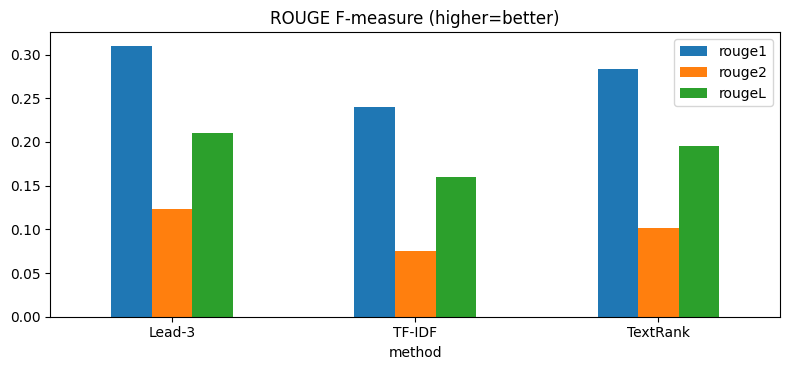

In [3]:
fig,ax=plt.subplots(figsize=(8,3.8))
res.set_index('method')[['rouge1','rouge2','rougeL']].plot(kind='bar',ax=ax); ax.set_title('ROUGE F-measure (higher=better)'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 3. Summary & takeaways

- **Lead-3 wins** (ROUGE-1 **0.310**, ROUGE-L 0.211) — beating both TextRank (0.283) and TF-IDF (0.240). This is the well-known **lead bias** of news writing: journalists put the most important facts in the first sentences, so 'just take the top' is hard to beat.
- **TextRank beats TF-IDF** — graph centrality (a sentence is important if similar to many others) is a better importance signal than raw TF-IDF weight, but neither overtakes lead-3 on news.
- **Extractive ROUGE is capped** because the references are *abstractive* (human-reworded) — an extractive system can never match wording it didn't select. Still, it is fast, unsupervised, and never hallucinates.
- **Takeaway**: always benchmark against the lead-3 baseline before claiming a summarizer 'works' on news — the trivial baseline is famously strong.